`MACHINE LEARNING | ANALÍA ELIZABETH GOMORY | ARGENTINA – SALTA 4400 | 2024`

**by Analía Elizabeth Gomory**

* ae.gomory@gmail.com

* http://www.linkedin.com/in/elizabeth-gomory-9240b1217

* https://ae-gomory.itch.io

* https://github.com/ElizabethGomory

* https://www.credly.com/users/analia-gomory

* https://orcid.org/0009-0003-0498-7658

* Descarga de Librerías y Archivos

In [72]:
from sklearn.cluster import KMeans
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn import metrics
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist


### **1.** Descarga de Base de Datos y Descripción

In [73]:
from sklearn import datasets
iris = datasets.load_iris()

In [74]:
print ('Atributos: ', iris.feature_names)
print ('Clases: ', iris.target_names)
print('Estructura: ', iris.data.shape)
print('Primeras 8 filas:')
print (iris.data [0:8])

Atributos:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases:  ['setosa' 'versicolor' 'virginica']
Estructura:  (150, 4)
Primeras 8 filas:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]]


* Conversión a Data Frame

In [75]:
irisdf = pd.DataFrame(iris.data, columns=iris.feature_names)
irisdf.head(8)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2


In [76]:
irisdf.describe()
irisdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


### **2.** Gráficos de Relaciones y Agrupamiento de Clusters

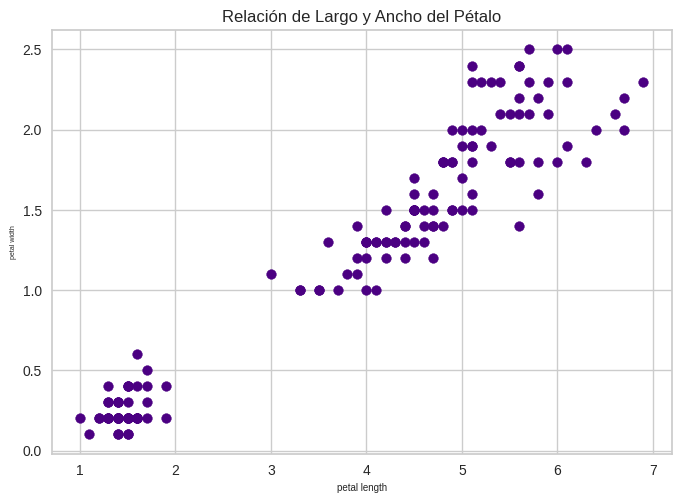

In [77]:
petal1= plt.scatter(x=irisdf['petal length (cm)'], y=irisdf['petal width (cm)'], c= 'indigo')
plt.xlabel('petal length', fontsize = 7)
plt.ylabel('petal width', fontsize = 5)
plt.title('Relación de Largo y Ancho del Pétalo')
plt.show()

Esta gráfica nos permite encontrar dos agrupaciones, una en su parte inferior (flores pequñas) y otra con características mas grandes en sus pétalos en ambas dimensiones.

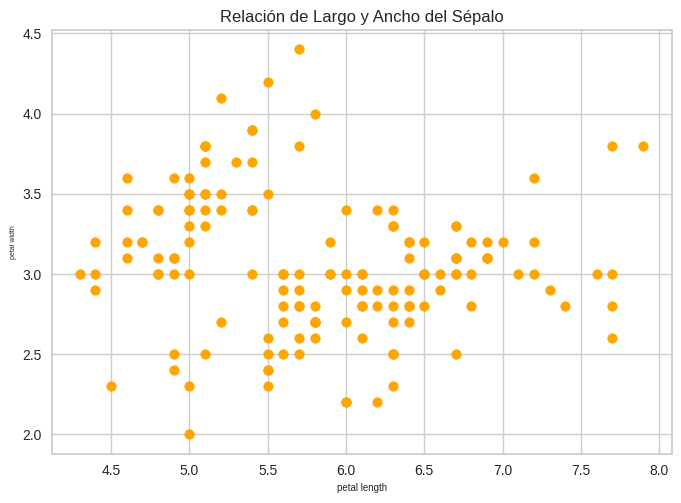

In [78]:
sepal2= plt.scatter(x=irisdf['sepal length (cm)'], y=irisdf['sepal width (cm)'], c= 'orange')
plt.xlabel('petal length', fontsize = 7)
plt.ylabel('petal width', fontsize = 5)
plt.title('Relación de Largo y Ancho del Sépalo')
plt.show()

Según su Sépalo, podemos encontrarnos con dos grupos más, casi similares, que varían más por su longitud que por su anchura.
Con ambos gráficos, podemos deducir que contamos con aproximadamente cuatro grupos.
Para comprobar la conjetura, visualizaremos en conjunto las gráficas.

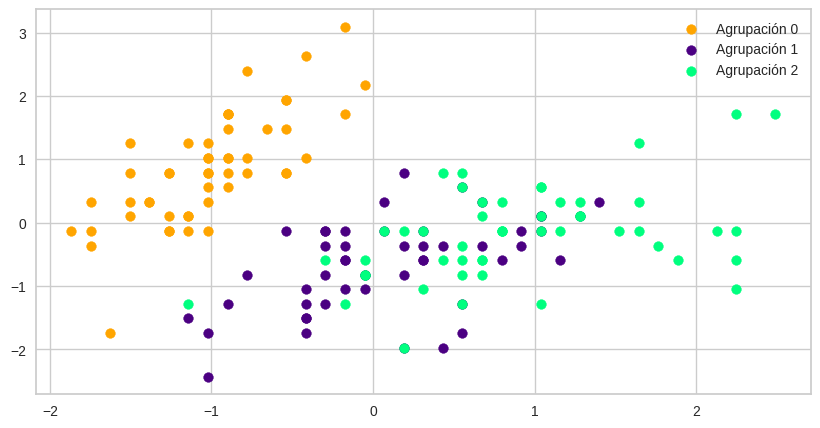

In [79]:
irisdf_scaled = scale(irisdf)
y=iris.target
aggiris= sepal2 , petal1
aggiris=plt.subplots(1, figsize=(10, 5))
color = ['orange', 'indigo','springgreen']
for i in np.unique(y):
    plt.scatter(x=irisdf_scaled[y==i, 0], y=irisdf_scaled[y==i, 1], c=color[i], label=f"Agrupación {i}")
    plt.legend()

De esta manera, logramos divisar 3 agrupaciones, de las cuales dos conjuntos podrían pertencer a un mismo grupo con las que trabajaremos en el entrenaimento.

### **3.**Entrenamiento del Modelo. Determinación de clusters: centros, inercia y etiqueta

In [80]:
km= KMeans(n_clusters=3, n_init = 10)
km= km.fit(irisdf)
print (km)

KMeans(n_clusters=3, n_init=10)


In [81]:
pd.DataFrame (km.cluster_centers_, columns = irisdf.columns)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,6.850000,3.073684,5.742105,2.071053
1,5.006000,3.428000,1.462000,0.246000
2,5.901613,2.748387,4.393548,1.433871


In [82]:
print ('Coordenadas de los Centroides')
print (km.cluster_centers_)
print( )
print ('Distancia entre Clusters')
print (km.inertia_)
print( )
print ('Etiquetas')
print (km.labels_)

Coordenadas de los Centroides
[[6.85       3.07368421 5.74210526 2.07105263]
 [5.006      3.428      1.462      0.246     ]
 [5.9016129  2.7483871  4.39354839 1.43387097]]

Distancia entre Clusters
78.851441426146

Etiquetas
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [83]:
irisdf['cluster'] = km.labels_
irisdf

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


### **4.** Graficar Clusters

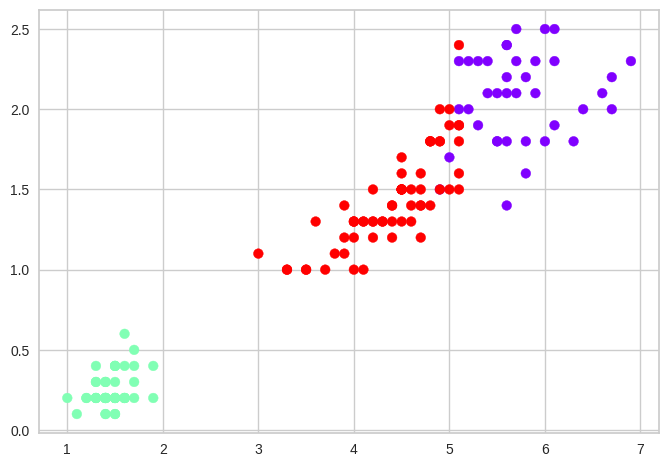

In [84]:
ggplot= plt.scatter(x=irisdf['petal length (cm)'],
                    y=irisdf['petal width (cm)'],
                    c=irisdf['cluster'],
                   cmap='rainbow',
                  )


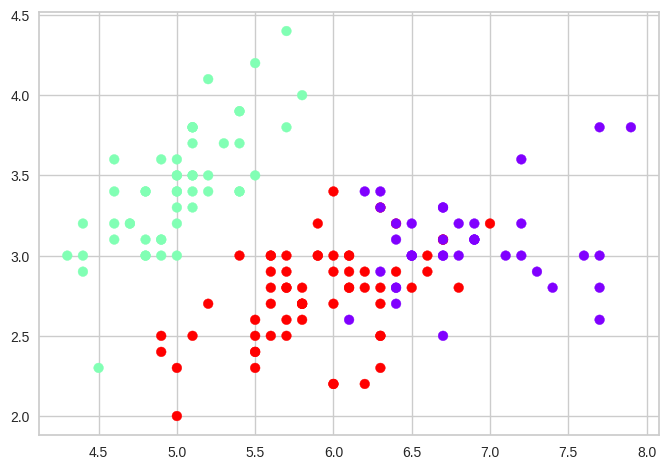

In [85]:
ggplot= plt.scatter(x=irisdf['sepal length (cm)'],
                    y=irisdf['sepal width (cm)'],
                    c=irisdf['cluster'],
                   cmap= 'rainbow',
                  )


### **5.** Método de Codo

In [86]:
see = []
numk =20
for k in range(1, numk):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(irisdf)
    see.append(kmeans.inertia_)

<Axes: >

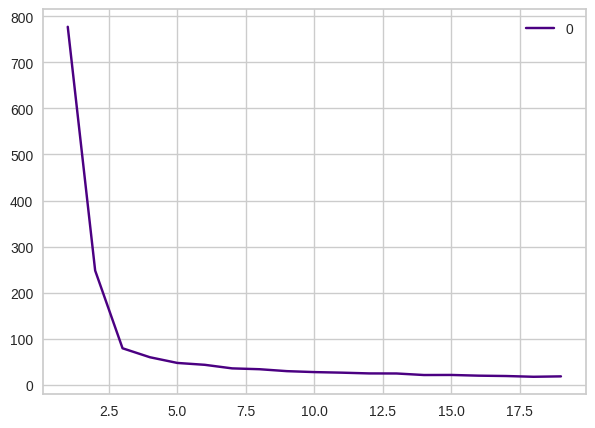

In [87]:
pd.DataFrame (see, index=np.arange (1,numk)).plot(figsize=[7,5], c='indigo')

El quiebre más significativo del método se encuentra cuando el resultado del cluster es 3, número que dedujimos en el segundo punto. Determinando así que este será el número de clústers ideal para realizar las agrupaciones.